## Esfinge: Modelo de comitê usando a abordagem Bagging e Meta Aprendizado

Aluno: Gabriel de Oliveira Paiva

O modelo de comitê é um modelo que funciona como um "comitê de modelos", onde suas respostas são algum tipo de combinação ou alguma resposta específica ( mais votada ) dos modelos envolvidos nele. Neste notebook usaremos como exemplo um comitê que será composto por um modelo de KNN, uma floresta aleatória e uma árvore de decisão. Será feito também um modelo Baseline para comparação de nosso modelo final. 

Neste notebook utilizaresmo os dados de pinguins apresentados durante a disciplina e disponível no módulo `seaborn` e a biblioteca destinada a aprendizado de máquina `scikit-learn`

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree

### Por que não usar sempre modelos individuais?

Essa pergunta é um tanto quanto coerente, se tenho um modelo e ele possui um bom desempenho, porque usar mais do que ele sozinho? Modelos nunca são perfeitos, e seus erros são ligados a forma com que são treinados e a própria estrutura que os torna o modelo que são. Por isso um modelo do tipo A pode ter um desempenho mais baixo em uma situação que o do tipo B funciona muito bem, e vice-versa. A analogia que modelos são super-heróis e que cada um tem sua prórpia "Criptonita" pode ajudar a compreender esta ideia. É importante lembrar que mesmo em que esse não seja o caso, um comitê possui algumas características estatísticas que podem ser úteis, justificando seu uso. Vamos ver essas situações para os modelos que usaremos neste material didático

**Floresta Aleatória**

É um modelo considerado robusto, mas pode não ser muito eficiente em situações em que o número de dados é pequeno, quando há muitos atributos irrelevantes ou quando a relação entre os dados é muito suave. Também pode apresentar dificuldades em problemas com classes muito desbalanceadas e, em tarefas de regressão não costuma ir bem em extrapolações fora do "alcance" de seu treinamento como se ele for treinado por um banco de dados de pessoas entre 20 e 60 anos, ele provavelmente terá dificuldade de prever características de pessoas fora desta faixa

**KNN**

É um modelo simples e que é muito útil, mas pode apresentar dificuldades quando há muitos atributos, pois as distâncias entre os exemplos tendem a se tornar menos informativas. Além de que é muito sensível a escolha do parâmetro K (Número de vizinhos que utiliza para fazer cada previsão).

**Árvore de decisão**

 Pode ser bastante sensível aos dados utilizados no treinamento ( O que em excesso pode ser ruim e levar ao overfitting) enquanto árvores muito simples podem não capturar adequadamente os padrões presentes nos dados. Além disso, pequenas alterações nos dados podem gerar árvores bastante diferentes, tornando o modelo mais instável.

Ao combinar estes 3 modelos em um comitê, esperamos que eles se complementem e que comitê se torne mais confiável e polivalente para analisar diferentes conjuntos de dados e que aumente sua eficácia de modo geral, mas com que estrátegia treinamos eles pensando em um comitê e não como modelos independentes?

### Relembrando alguns conceitos...

Aqui temos uma breve definição de alguns conceitos básicos que acredito eu que você já tenha tido contato, caso tenha alguma dúvida ou insegurança recomendo que revisite os notebooks do Professor Cassar que os abordam de forma mais profunda e completa.

**Viés:**

 O viés está relacionado aos erros causados por simplificações excessivas do modelo. Quando o modelo é muito simples, ele pode não conseguir aprender os padrões mais importantes dos dados, resultando em um desempenho abaixo do esperado. Esse comportamento é conhecido como underfitting.

**Variância:**

 A variância representa o quanto as previsões de um modelo mudam quando há pequenas alterações nos dados de treinamento. Modelos com alta variância tendem a se adaptar demais aos exemplos utilizados no treinamento, capturando até mesmo ruídos e particularidades dos dados. Esse fenômeno é chamado de overfitting e geralmente reduz a capacidade de generalização do modelo.

**Equilíbrio Viés–Variância:** 

O equilíbrio entre viés e variância consiste em encontrar um nível adequado de complexidade para o modelo. Modelos muito simples podem apresentar alto viés, enquanto modelos muito complexos podem apresentar alta variância. O objetivo é obter um modelo capaz de aprender os padrões relevantes dos dados sem se ajustar excessivamente aos detalhes específicos do conjunto de treinamento.

**Covariância:** 

A covariância mede como duas variáveis variam em conjunto. Quando ambas tendem a aumentar ou diminuir simultaneamente, a covariância assume valores positivos; quando se comportam em direções opostas, assume valores negativos. Em Ensemble Learning, esse conceito ajuda a analisar o quanto diferentes modelos apresentam comportamentos ou erros semelhantes.

**Correlação:** 

A correlação indica a força e a direção da relação entre duas variáveis em uma escala padronizada. Valores próximos de 1 indicam uma forte relação positiva, enquanto valores próximos de -1 indicam uma forte relação negativa. Em ensembles, modelos com baixa correlação entre seus erros costumam contribuir mais para a melhoria do desempenho, pois fornecem previsões mais diversificadas.

### Conceito de Bagging

Você pode usar várias estrátegias diferentes mas no nosso caso usaremos o _bagging_ ( abreviação para _Bootstrap Aggregating_) que consiste em treinar nossos modelos com partes dos nossos dados, essas partes não são iguais, mas podem conter exemplos em comum.

Representação do Bagging

<img alt="célula" src="https://www.oreilly.com/api/v2/epubs/urn:orm:book:9781788830577/files/assets/a942be0b-22b5-45c0-9fbf-007ec88a7e7e.png" width="500px">

***Fonte:https://www.oreilly.com/library/view/machine-learning-quick/9781788830577/6f97f4fd-5b34-4d7b-bb48-ec156c6262b1.xhtml***

Certo, agora vamos entender o como isso funciona e porque faz sentido:

vamos supor que treinaremos:

$$ f_1(x), f_2(x), \ldots, f_B(x) $$
Para cada $f_i(x)$ é feito um treinamento com um bootstrap diferente, ou seja cada modelo pode realizar uma previsão diferente para um mesmo x
por exemplo: $$f_a(x)=10$$ $$f_b(x)=11$$ $$f_c(x)=9$$
A partir disso o Bagging faz a média, ou seja:
$${f}_{bag}(x) = \frac{1}{B}\sum_{b=1}^{B} f_b(x)$$

A resposta nesse caso seria a média dos valores considerando cada voto do comitê. Discutiremos sobre a combinação das respostas mais a fundo adiante, não se preocupe muito com isso agora a ideia é o uso de um exemplo para o Baggin, Essas são as operações básicas que ele pode fazer no caso de serem modelos de regressão, mas como isso afeta a variância e o viés do comitê?

Podemos representar cada previsão de um modelo individual como $${f}_{bag} = f(x) + \varepsilon_b$$

 Assim, a predição obtida pelo Bagging é dada pela média das previsões dos $B$ modelos, ou seja,
 
  $${f}_{bag} = \frac{1}{B}\sum_{b=1}^{B}[f(x)+\varepsilon_b]$$
  
   Distribuindo a soma, obtém-se:
   $${f}_{bag} = f(x) + \frac{1}{B}\sum_{b=1}^{B}\varepsilon_b$$
   
   Dessa forma, o erro do comitê pode ser escrito como a média dos erros dos modelos envolvidos $$\varepsilon_{bag} = \frac{1}{B}\sum_{b=1}^{B}\varepsilon_b$$ 
    
mostrando que o Bagging transforma o erro do comitê na média dos erros dos modelos individuais. Para analisar a variância do método, consideramos a variância da predição agregada, dada por $$\mathrm{Var}({f}_{bag}) = \mathrm{Var}\left(\frac{1}{B}\sum_{b=1}^{B}{f}_{bag}\right)$$ Aplicando a propriedade $$\mathrm{Var}(aX) = a^2\mathrm{Var}(X)$$ obtemos: $$\mathrm{Var}({f}_{bag}) = \frac{1}{B^2}\mathrm{Var}\left(\sum_{b=1}^{B}{f}_{bag}\right)$$


No caso ideal considerando que os modelos são independentes, temos
 $$\operatorname{Cov}({f}_{a},{f}_{b})=0,\quad {f}_{a}\neq {f}_{b}.$$
  Então, a variância da média dos modelos é dada por

   $$\operatorname{Var}({f}_{bag})=\frac{1}{B^2}\sum_{i=1}^{B}\operatorname{Var}({f}_b).$$

Se todos os modelos possuem a mesma variância, isto é:
 $$\operatorname{Var}({f}_{a})=\sigma^2,$$ 
então obtemos:
 $$\operatorname{Var}({f}_{bag})=\frac{1}{B^2}B\sigma^2=\frac{\sigma^2}{B}.$$ 
Portanto: 
$${\operatorname{Var}({f}_{bag})=\frac{\sigma^2}{B}}$$ 
A quantidade de modelos é inversamente proporcional a variância no Bagging para regressão. Assim, quando aumentamos o número de modelos em um comitê tendemos a diminuir a variância do comitê. Porém nossos modelos não são totalmente independentes já que são treinados com partes diferentes dos mesmos dados, por isso temos que:
  $$\operatorname{Corr}({f}_{a},{f}_{b})=\rho.$$
  Como:
  $$\operatorname{Cov}({f}_{a},{f}_{b})=\rho\sigma^2,$$
  podemos chegar a:
  $$\operatorname{Var}({f}_{bag})=\frac{\sigma^2}{B}+\frac{B-1}{B}\rho\sigma^2,$$
  Reorganizando, obtemos
  $${\operatorname{Var}({f}_{bag})=\sigma^2\left(\rho+\frac{1-\rho}{B}\right)}.$$

Agora podemos fazer outra dedução importante. A média do comitê é dada por

$$
E[{f}_{bag}] = E\left[\frac{1}{B}\sum_{b=1}^{B}{f}_b\right].
$$

Pela linearidade da esperança,

$$
E[{f}_{bag}] = \frac{1}{B}\sum_{b=1}^{B}E[{f}_b].
$$

Se todos os modelos possuem o mesmo viés,

$$
\operatorname{Viés}({f}_{b})=\beta,
$$

então:

$$
\operatorname{Viés}({f}_{bag})=\beta.
$$

Ou seja, o Bagging é especialmente eficiente para reduzir a variância, mas não necessariamente reduz o viés. 

Para regressão, o erro quadrático médio (MSE) do comitê pode ser escrito como

$$
MSE = \operatorname{Viés}^2 + \operatorname{Var} + \sigma_{\varepsilon}^{2}.
$$

Vale ressaltar que aumentar o número de modelos indefinidamente reduz a variância até um certo ponto, ou seja um número de modelos tendendo a infinito a variância não será zero, e será ainda maior se eles forem correlacionados entre si (O que acontece na maioria das vezes)

Agora vamos entender como o comitê e suas características se aplicam quando temos um problema de classificação. Para este exemplo usaremos a associação na ideia de votação majoritária mas não se preocupe com isso neste momento, falaremos mais sobre essa temática adiante

$$
Y \in \{0,1\}.
$$

Cada modelo produz:

$$
f_b(x) \in \{0,1\}.
$$

O Bagging utilizando votação majoritária:

$$
{f}_{bag} = \operatorname{modelo}\left\{f_1(x),f_2(x),\ldots,f_b(x)\right\}.
$$

Aqui temos uma dedução muito interessante. Suponha que cada modelo tenha probabilidade de erro

$$
P(\text{erro}) = p.
$$

Se assumirmos, para simplificar, que os erros são independentes, o comitê comete erro quando mais da metade dos modelos erram.

Para $B$ modelos ímpares:

$$
P(\text{erro do comitê})
=
\sum_{k=(B+1)/2}^{B}
\binom{B}{k}
p^k(1-p)^{B-k}.
$$

Essa equação é a versão classificatória da redução de variância.


Imagine que temos 100 modelos, mas todos cometem praticamente os mesmos erros. Por exemplo,

$$
f_1(x)=f_2(x)=\cdots=f_{100}(x)
$$

Então,

$$
\rho \approx 1
$$

A votação não acrescenta praticamente nenhuma informação. É quase como ter

$$
1 \text{ modelo} \times 100
$$

Por outro lado, se os modelos cometem erros diferentes,

$$
\rho \approx 0
$$

a votação consegue cancelar parte desses erros.

Portanto,

$$
\text{Baixa correlação entre erros} \Rightarrow \text{maior benefício do Bagging}
$$

Ou seja modelos que erram de formas não correlacionadas formam um comitê que tende a errar menos, isso nos explicita a importância que a variedade de modelos tem para a formação de um bom comitê

### Limitações e ponderações do Comitê com Bagging

A principal característica do Bagging como vimos acima é diminuir a variância, o que o torna menos sensível a particularidades do conjunto de treinamento, porém isso não protege o nosso comitê de ter problemas com relação ao **viés**. Por exemplo um comitê formado por um conjunto de modelos muito simples podem apresentar alto viés mas fazer um comitê deles não resolve o problema da baixa flexibilidade dos modelos e consequentemente do comitê.

**Diferença entre modelos** : É um ponto fundamental para entendermos quando devemos ou não usar o comitê com Bagging, se os seus modelos forem muito semelhantes apenas o treinamento com diferentes porções dos dados pode não ser suficiente para diversificar as respostas dos modelos, o que faz com que oganho em perda de variãncia seja muito pequeno quando comparado aos modelos individuais.

**Custo computacional** Caso seu comitê tenha muitos modelos ou o ganho com a combinação deles seja pequeno talvez não faça sentido o custo adicional de treinar vários modelos e combiná-los no lugar de treinar apenas um modelo.

**Interpretação** A depender dos critérios de votação e do número de modelos pode se tornar um modelo não tão simples de interpretar ou de entender o porquê que o modelo se comporta de jeito x em determinada situação

### Ajustando o Banco de Dados

Sabemos que precisamos entender e trabalhar nossos dados antes de treinar nossos modelos, então vamos lá!

Conhecendo nosso dados:

In [18]:
NOME_DATASET = "penguins"
df = sns.load_dataset(NOME_DATASET)
print(df.columns)

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')


In [19]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Vamos utilizar neste trabalho os atributos de massa do pinguins, tamanho da nadadeira e tamanho do bico (X) para tentar prever a profundidade do bico (y). 

In [20]:
df = df.dropna()
ATRIBUTOS = ["bill_length_mm", "flipper_length_mm", "body_mass_g"]
TARGET = ["bill_depth_mm"]
X = df[ATRIBUTOS]
y = df[TARGET]

In [21]:
X

,bill_length_mm,flipper_length_mm,body_mass_g
0,39.1,181.0,3750.0
1,39.5,186.0,3800.0
2,40.3,195.0,3250.0
4,36.7,193.0,3450.0
5,39.3,190.0,3650.0
...,...,...,...
338,47.2,214.0,4925.0
340,46.8,215.0,4850.0
341,50.4,222.0,5750.0
342,45.2,212.0,5200.0


In [22]:
y

,bill_depth_mm
0,18.7
1,17.4
2,18.0
4,19.3
5,20.6
...,...
338,13.7
340,14.3
341,15.7
342,14.8


In [23]:
# Criando Arrays e garantindo que o y tenha 1 dimensão
X_array = X.values
y_array = y.values.ravel()

### O modelo KNN

Vamos treinar dois modelos para nosso estudo! Um modelo KNN pensado para atuar sozinho e outro para construirmos nosso comitê utilizando Bagging.

Primeiro vamos treinar o que vai atuar sozinho:

In [24]:
TAMANHO_TESTE = 0.1 # Esse valor será usado em todos os modelos individuais
SEMENTE_ALEATORIA = 42 # Esse valor será usado em todos os modelos individuais
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_array,
    y_array,
    test_size=TAMANHO_TESTE,
    random_state=SEMENTE_ALEATORIA
)
print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

X_treino: (299, 3)
X_teste: (34, 3)
y_treino: (299,)
y_teste: (34,)


In [25]:
NUM_VIZINHOS = 3
modelo_knn_individual = KNeighborsRegressor(
    n_neighbors=NUM_VIZINHOS
)
modelo_knn_individual.fit(X_treino, y_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


### A Árvore de Decisão

In [26]:
# Mesma estrutura utilizada anteriormente, deixada aqui só para registro
TAMANHO_TESTE = 0.1
SEMENTE_ALEATORIA = 42
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_array,
    y_array,
    test_size=TAMANHO_TESTE,
    random_state=SEMENTE_ALEATORIA
)
print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

X_treino: (299, 3)
X_teste: (34, 3)
y_treino: (299,)
y_teste: (34,)


In [27]:
PROFUNDIDADE=5
modelo_arvore_individual = DecisionTreeRegressor(
    random_state=42,
    max_depth=PROFUNDIDADE,
)
modelo_arvore_individual.fit(X_treino, y_treino)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``

In [28]:
y_verdadeiro = y_teste
y_previsto = modelo_arvore_individual.predict(X_teste)

RMSE = root_mean_squared_error(y_verdadeiro, y_previsto)

print(f"O RMSE do modelo árvore de decisão foi de {RMSE} unidades de y.")

O RMSE do modelo árvore de decisão foi de 0.9557587603687598 unidades de y.


In [29]:
from sklearn.metrics import root_mean_squared_error

# Previsões
y_pred_treino = modelo_arvore_individual.predict(X_treino)
y_pred_teste = modelo_arvore_individual.predict(X_teste)

# RMSE
rmse_treino = root_mean_squared_error(y_treino, y_pred_treino)
rmse_teste = root_mean_squared_error(y_teste, y_pred_teste)

print(f"RMSE treino: {rmse_treino:.4f}")
print(f"RMSE teste : {rmse_teste:.4f}")

RMSE treino: 0.8414
RMSE teste : 0.9558


In [30]:
NUM_FOLHAS = [None, 6, 36]
NUM_PROFUNDIDADE = [None, 3, 10]

for n_folhas, n_profundidade in product(NUM_FOLHAS, NUM_PROFUNDIDADE):
    modelo = DecisionTreeRegressor(
        max_leaf_nodes=n_folhas,
        max_depth=n_profundidade,
    )
    modelo.fit(X_treino, y_treino)
    y_verdadeiro = y_teste
    y_previsao = modelo.predict(X_teste)
    RMSE = root_mean_squared_error(y_verdadeiro, y_previsao)

    print(
        f"O RMSE do modelo AD usando max_leaf_nodes={n_folhas} "
        f"e max_depth={n_profundidade} foi de {RMSE:.2f} unidades de y.")

O RMSE do modelo AD usando max_leaf_nodes=None e max_depth=None foi de 1.17 unidades de y.
O RMSE do modelo AD usando max_leaf_nodes=None e max_depth=3 foi de 0.86 unidades de y.
O RMSE do modelo AD usando max_leaf_nodes=None e max_depth=10 foi de 1.03 unidades de y.
O RMSE do modelo AD usando max_leaf_nodes=6 e max_depth=None foi de 0.89 unidades de y.
O RMSE do modelo AD usando max_leaf_nodes=6 e max_depth=3 foi de 0.89 unidades de y.
O RMSE do modelo AD usando max_leaf_nodes=6 e max_depth=10 foi de 0.89 unidades de y.
O RMSE do modelo AD usando max_leaf_nodes=36 e max_depth=None foi de 0.83 unidades de y.
O RMSE do modelo AD usando max_leaf_nodes=36 e max_depth=3 foi de 0.86 unidades de y.
O RMSE do modelo AD usando max_leaf_nodes=36 e max_depth=10 foi de 0.85 unidades de y.


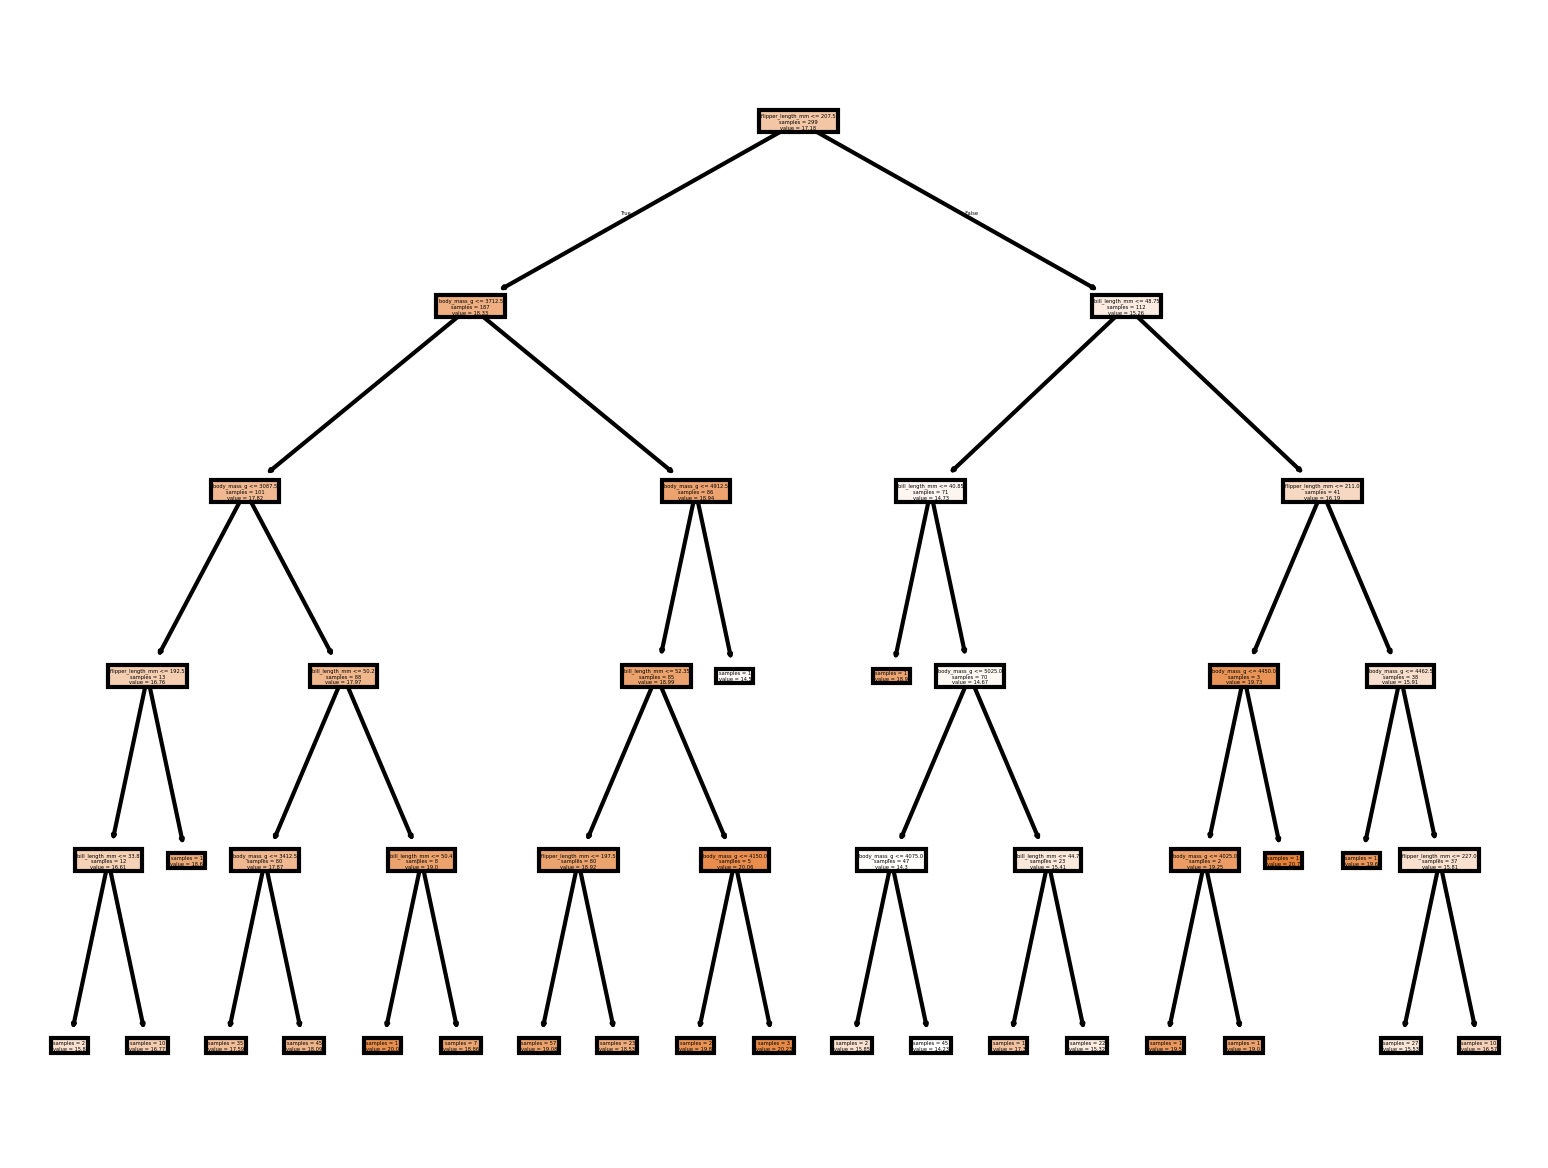

In [31]:
figura, eixo = plt.subplots(dpi=300)
plot_tree(
    modelo_arvore_individual,
    feature_names=ATRIBUTOS,
    ax=eixo,
    impurity=False,
    filled=True,
    proportion=False,
    precision=2,
)
plt.show()

### A Floresta Aleatória

In [32]:
# Mesma estrutura utilizada anteriormente, deixada aqui só para registro
TAMANHO_TESTE = 0.1
SEMENTE_ALEATORIA = 42
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_array,
    y_array,
    test_size=TAMANHO_TESTE,
    random_state=SEMENTE_ALEATORIA
)
print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

X_treino: (299, 3)
X_teste: (34, 3)
y_treino: (299,)
y_teste: (34,)


### O Baseline

### O modelo de Comitê

### Votação Rigorosa e Votação Suave

### Resultados e comparações

### Utilização de IA no desenvolvimento do trabalho

### Referências:

BREIMAN, Leo. Bagging predictors. Machine Learning, Dordrecht, v. 24, n. 2, p. 123-140, 1996. Disponível em: <https://www.stat.berkeley.edu/~breiman/bagging.pdf>.

IZBICKI, Rafael; SANTOS, Tiago Mendonça dos. Aprendizado de máquina: uma abordagem estatística. 1. ed. Curitiba: Alta Books, 2020.

SCIKIT-LEARN. 1.11. Ensembles: Gradient boosting, random forests, bagging, voting, stacking. Scikit-learn Documentation, [S. l.], 2025. Disponível em: <https://scikit-learn.org/stable/modules/ensemble.html>.

KUMAR, Rahul. Bagging. In: KUMAR, Rahul. Machine Learning Quick Reference. Birmingham: Packt Publishing, 2019. Disponível em: <https://www.oreilly.com/library/view/machine-learning-quick/9781788830577/6f97f4fd-5b34-4d7b-bb48-ec156c6262b1.xhtml>